# ENEL 441 Lab 1 - Prelab
# Understanding The Frequency Domain Representation

In this prelab you will:
1. Derive the model of the lab equipment that you will be using in the lab. 
2. Learn about some of the intricacies of dealing with sinusoidal data in the frequency domain.
3. Setup your Python environment with the right packages.

This will help make the lab a better learning experience. 

# Part 1 - Modelling The Lab Equipment

# Diagram of the lab equipment

In the lab you will be investigating a rotational mechanical system with two sets of weighted disks as shown in the figure below. 

![2 Disk Graphic Diagram](2diskGraphic.png "2 Disk Graphic Diagram")

A torque is applied by a motor to a system with two disks. The disks are connected by a thin flexible rod. The rod is supported by bearings on both sides of the disks. The torque applied by the motor is the input (we will assume that it is propotional to voltage). The angular position of the right disk is measured. 

In the first part of the pre-lab you will:
- Derive governing differential equations,
- Construct a transfer function representation of the system
- Construct a frequency domain representation of the system (a Bode plot) 


# Schematic Diagram

The schematic diagram for the system is shown in the figure below, where:
- $\theta_1$ and $\theta_2$ are the positions of disks 1 and 2 respectively,
- $J_1$ and $J_2$ are the moment of inertia's of disks 1 and 2 respectively,
- $k_1$ and $k_2$ are the spring constants of rods 1 and 2 respectively,
- $b_1$ and $b_2$ are the coefficients of friction in the bearings for bearings 1 and 2 respectively.

![2 Disk Schematic Diagram](2diskSchematic.png "2 Disk Schematic Diagram")

# Free Body Diagram

Because there are two moments of inertia in this system, we have two free body diagrams, as shown below.

![2 Disk Free Body Diagram](2diskFreeBody.png "2 Disk Free Body Diagram")

# Question 1

Derive the governing differential equations for each disk. You should end up with two differential equations, one for each disk.

Disk 1:
$$\sum T_1 = J_1\ddot\theta_1$$
$$J_1\ddot\theta_1 = -b_1\dot\theta_1 - k\theta_1 + k\theta_2 + T_M$$
$$\boxed{J_1\ddot\theta_1 + b_1\dot\theta_1 + k\theta_1 = k\theta_2 + T_M}$$

Disk 2:
$$\sum T_2 = J_2\ddot\theta_2$$
$$J_2\ddot\theta_2 = -b_2\dot\theta_2 - k\theta_2 + k\theta_1$$
$$\boxed{J_2\ddot\theta_2 + b_2\dot\theta_2 + k\theta_2 = k\theta_1}$$

# Question 2

Using the two equations, find the transfer function from motor torque, $T_M$, to the angle of the second disk, $\theta_2$. You can assume that the system is initially at rest (i.e. initial conditions are zero).

Hint 1: this will require you to substitute one of the equations into the other. 

Hint 2: the left hand side of your equation should be $\frac{\Theta_2(s)}{T_M(s)} = \cdots$.

Eq. 1:
$$s^2J_1\Theta_1(s)+sb_1\Theta_1(s)+k\Theta_1(s)=k\Theta_2(s)+T_M(s)$$
$$(s^2J_1+sb_1+k)\Theta_1(s)=k\Theta_2(s)+T_M(s)$$

Eq. 2:
$$s^2J_2\Theta_2(s)+sb_2\Theta_2(s)+k\Theta_2(s)=k\Theta_1(s)$$
$$(s^2J_2+sb_2+k)\Theta_2(s)=k\Theta_1(s)$$
$$\frac{(s^2J_2+sb_2+k)\Theta_2(s)}{k}=\Theta_1(s)$$

Substitute Eq. 2 into Eq. 1 $k\Theta_1(s)$:
$$\frac{(s^2J_1+sb_1+k)(s^2J_2+sb_2+k)\Theta_2(s)}{k}=k\Theta_2(s)+T_M(s)$$
$$\frac{(s^2J_1+sb_1+k)(s^2J_2+sb_2+k)\Theta_2(s)}{k}-k\Theta_2(s)=T_M(s)$$
$$\frac{(s^2J_1+sb_1+k)(s^2J_2+sb_2+k)\Theta_2(s)-k^2\Theta_2(s)}{k}=T_M(s)$$
$$\boxed{\frac{\Theta_2(s)}{T_M(s)}=\frac{k}{(s^2J_1+sb_1+k)(s^2J_2+sb_2+k)-k^2}}$$

# Question 3

Use Python to make a Bode plot of the system. At what frequency is the resonant peak? What does this tell you about the poles of the system? 

Hint: use the code snippet below

The resonant peak is at a frequency of approximately $7.7\times10^{-1}\ \text{rad/s}$. This tells us that there are complex conjugate poles with imaginary components close to this frequency.

<TransferFunction>: sys[76]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  1
  ---------------------------------
  25 s^4 + 3.75 s^3 + 15.12 s^2 + s


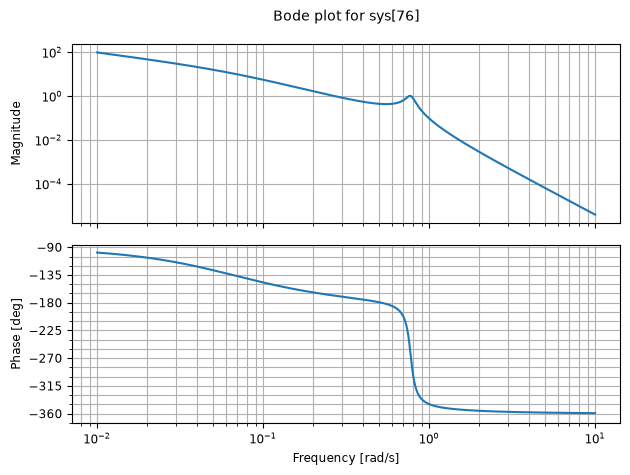

In [72]:
import control as ct
import numpy as np

J1 = 10
J2 = 5
k = 2
b = 0.5

num_sys = np.array([1])
den_sys = np.array([J1*J2/k, (J1+J2)*b/k, (J1+J2+b**2/k), 2*b, 0])

P = ct.tf(num_sys,den_sys)
print(P)

out = ct.bode_plot(P)


# Part 2 - Sinusoids in practice

Recall that the Fourier Series is used to represent periodic signals, and the Fourier Transform is used to represent aperiodic signals (signals that are not periodic). The Fourier Transform of a periodic signal is the same as the Fourier Series. 

Secondly, recall that the Fourier Series representation of a sinusoid is a set of spikes in the Frequency domain:
$$
\mathcal{F}[\cos(\omega t)] = \frac{1}{2}\delta(-\omega) + \frac{1}{2}\delta(\omega)
$$

This makes sense because a sinusoid consists of a signal with power at only one frequency. 

Thirdly, recall that the Fourier Tranform is symmetric in the positive and negative frequencies.

This is illustrated in the code below.

In [73]:
import numpy as np
import matplotlib.pyplot as plt

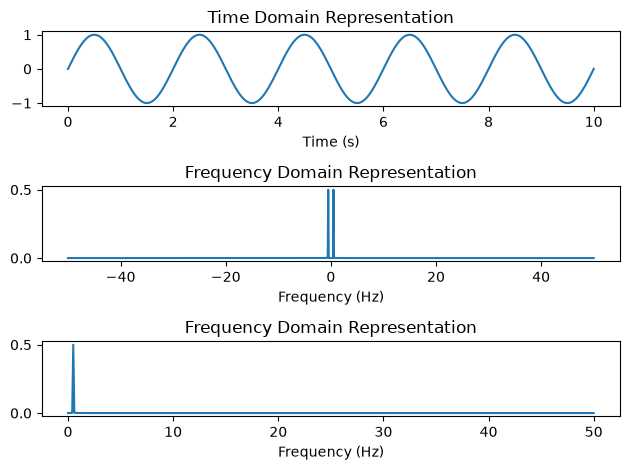

In [74]:
# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

# construct a signal that consists of a sinusoid with frequency 0.5Hz
f0 = 0.5
sig = np.sin(2*np.pi*f0*t)

# Calculate the Fourier Transform using the command fft (which stands for fast Fourier Transform)
# Note that the fft command does not normalize the output, so we need to manually divide the resulting signal by N
Sig = np.fft.fft(sig)/N

# We need to shift the frequency axis of Sig so that 0Hz is the center frequency
Sig = np.fft.fftshift(Sig) 

# In this lab, we will only be interested in the magnitude of the frequency domain representation 
# (recall that typically the array Sig will be a set of complex numbers).
Sig = np.abs(Sig)


# Because the frequency domain is symetric about $0$Hz, we can limit the plot to positive frequencies only
Sig_positive_freq = Sig[500:1001]
f_positive_freq = f[500:1001]


# Plot the signal in time domain and frequency domain
fig,ax = plt.subplots(3,1)
ax[0].plot(t,sig)
ax[0].set_title('Time Domain Representation')
ax[0].set_xlabel('Time (s)')
ax[1].plot(f,Sig)
ax[1].set_title('Frequency Domain Representation')
ax[1].set_xlabel('Frequency (Hz)')
ax[2].plot(f_positive_freq,Sig_positive_freq)
ax[2].set_title('Frequency Domain Representation')
ax[2].set_xlabel('Frequency (Hz)')
fig.tight_layout()


# Question 1

Verify in code that the spikes occur at the right frequencies. 

Hint 1: The frequency domain representation is symmetric about $0$ Hz. So you only need to look at the second half of the plot containing the freuency range $0$ Hz to $50$ Hz. 

Hint 2: The command np.argmax() returns the index in the array of the maximum value in the array. Use this to give you the index of the spike in the array Sig. Now that you know the index of the maximum value, you can use the frequency vector f, to determine the frequency that corresponds to that index.  

In [75]:
# your code here
print(f'Index = {np.argmax(Sig_positive_freq)}')
print(f'Frequency = {f_positive_freq[np.argmax(Sig_positive_freq)]} Hz')

Index = 5
Frequency = 0.5 Hz


# Question 2

Determine the magnitude of the sinusoid using the frequency domain plot only. Verify your answer by looking at the magnitude of the sinuoid in the time domain. 

In [76]:
# your code here
print(f'Magnitude = {np.max(Sig_positive_freq) * 2}')


Magnitude = 0.9994590654933457


# Question 3

When we use measured data, there are some typical situations that occur that can have a large effect on analyzing the data. The first thing that can happen is that the sinusoid is not zero mean. How does this affect the frequency domain representation of the sinusoid? Give a mathematical explanation of what you are observing in the plot below.

The offset adds a spike to the frequency domain representation of the sinusoid at $0$, mathematically this is taking the Fourier Transform of a sinusoid and a constant component, i.e., $\mathcal F\{A\sin \omega t+B\}$, which gives frequency components at $\pm\omega$ and $0$.

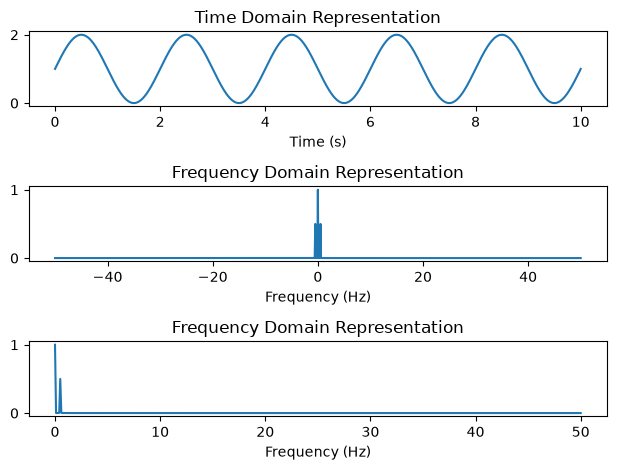

In [77]:
# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

# construct a signal that consists of a sinusoid with frequency 0.5Hz
f0 = 0.5
sig_offset = np.sin(2*np.pi*f0*t) + 1

# Calculate the Fourier Transform using the command fft (which stands for fast Fourier Transform)
# Note that the fft command does not normalize the output, so we need to manually divide the resulting signal by N
Sig_Offset = np.fft.fft(sig_offset)/N

# We need to shift the frequency axis of Sig so that 0Hz is the center frequency
Sig_Offset = np.fft.fftshift(Sig_Offset) 

# In this lab, we will only be interested in the magnitude of the frequency domain representation 
# (recall that typically the array Sig will be a set of complex numbers).
Sig_Offset = np.abs(Sig_Offset)


# Because the frequency domain is symetric about $0$Hz, we can limit the plot to positive frequencies only
Sig_Offest_positive_freq = Sig_Offset[500:1001]
f_positive_freq = f[500:1001]


# Plot the signal in time domain and frequency domain
fig,ax = plt.subplots(3,1)
ax[0].plot(t,sig_offset)
ax[0].set_title('Time Domain Representation')
ax[0].set_xlabel('Time (s)')
ax[1].plot(f,Sig_Offset)
ax[1].set_title('Frequency Domain Representation')
ax[1].set_xlabel('Frequency (Hz)')
ax[2].plot(f_positive_freq,Sig_Offest_positive_freq)
ax[2].set_title('Frequency Domain Representation')
ax[2].set_xlabel('Frequency (Hz)')
fig.tight_layout()


# Question 4

The second thing that can happen when we have measured data is that the measured data has a trend. This is often caused by gears that are not meshing perfectly. How does a trend affect the frequency domain representation of the sinusoid? Give a mathematical explanation of what you are observing in the plot below.

Hint: The Fourier transform of a ramp is:
$$
\mathcal{F}[t1(t)] = \frac{1}{(j\omega)^2}
$$

Use the same method as in Question 2 to estimate the magnitude of the sinusoid from frequency domain data. Is the estimate accurate? 

The trend adds a reciprocal function centered at $0$ that the frequency components of the sinusoid sum with. This is because the Fourier Transform of a ramp is $1/(j\omega)^2$ which creates a squared reciprocal. Adding this component to the sinusoid components makes the estimate not perfectly accurate.

Magnitude of sinusoid: 0.6808177921551798


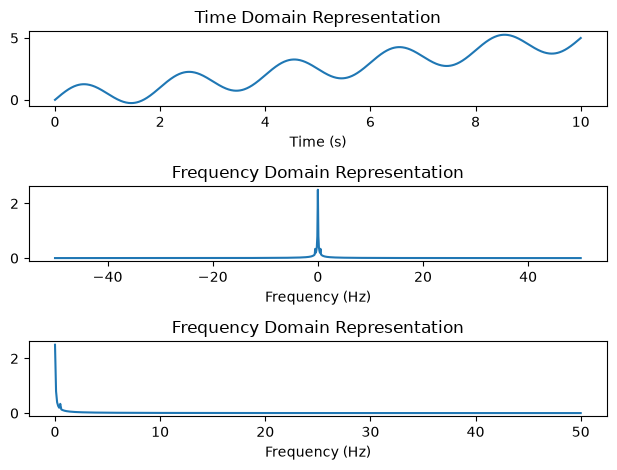

In [78]:
# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

# construct a signal that consists of a sinusoid with frequency 0.5Hz
f0 = 0.5
sig_trend = np.sin(2*np.pi*f0*t) + 0.5*t

# Calculate the Fourier Transform using the command fft (which stands for fast Fourier Transform)
# Note that the fft command does not normalize the output, so we need to manually divide the resulting signal by N
Sig_Trend = np.fft.fft(sig_trend)/N

# We need to shift the frequency axis of Sig so that 0Hz is the center frequency
Sig_Trend = np.fft.fftshift(Sig_Trend) 

# In this lab, we will only be interested in the magnitude of the frequency domain representation 
# (recall that typically the array Sig will be a set of complex numbers).
Sig_Trend = np.abs(Sig_Trend)


# Because the frequency domain is symetric about $0$Hz, we can limit the plot to positive frequencies only
Sig_Trend_positive_freq = Sig_Trend[500:1001]
f_positive_freq = f[500:1001]

mag_spike = np.max(Sig_Trend_positive_freq[3:-1])
print('Magnitude of sinusoid:', mag_spike*2)


# Plot the signal in time domain and frequency domain
fig,ax = plt.subplots(3,1)
ax[0].plot(t,sig_trend)
ax[0].set_title('Time Domain Representation')
ax[0].set_xlabel('Time (s)')
ax[1].plot(f,Sig_Trend)
ax[1].set_title('Frequency Domain Representation')
ax[1].set_xlabel('Frequency (Hz)')
ax[2].plot(f_positive_freq,Sig_Trend_positive_freq)
ax[2].set_title('Frequency Domain Representation')
ax[2].set_xlabel('Frequency (Hz)')
fig.tight_layout()


# Question 5

The third thing that commonly happens when we have measured data is that the measured data does not have an integer number of complete sinusoids. How does this affect the frequency domain representation of the sinusoid? Give an explanation of what you are observing in the plot below in terms of the difference between a Fourier Series and a Fourier Transform. Is the time domain signal in the plot periodic from the point of view of the Fourier Series and the Fourier Transform?

Calculate the magnitude of the sinusoid using the frequency domain plot. Is this an accurate estimate of the magnitude of the sinusoid? What is the correct magnitude of the sinusoid?

The frequency domain represention of the sinusoid becomes two imperfect peaks that round off at the bottom. The time domain signal is periodic from a Fourier Series view and aperiodic from a Fourier Transform view. The magnitude estimate will be inaccurate, for this sinusoid the magnitude is $1$.

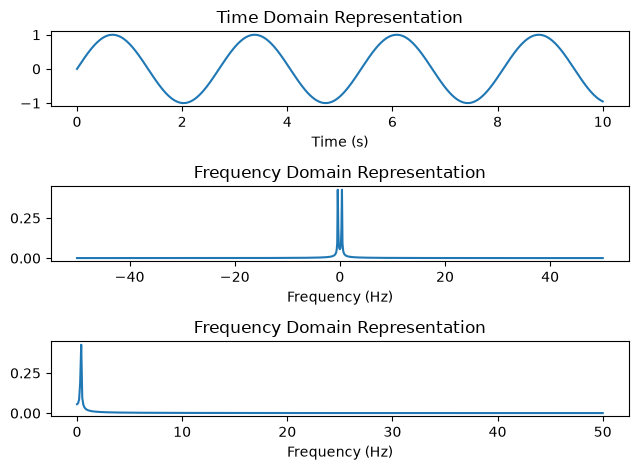

In [79]:
# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

# construct a signal that consists of a sinusoid with frequency 0.33Hz
f0 = 0.37
sig_cutoff = np.sin(2*np.pi*f0*t) 

# Calculate the Fourier Transform using the command fft (which stands for fast Fourier Transform)
# Note that the fft command does not normalize the output, so we need to manually divide the resulting signal by N
Sig_Cutoff = np.fft.fft(sig_cutoff)/N

# We need to shift the frequency axis of Sig so that 0Hz is the center frequency
Sig_Cutoff = np.fft.fftshift(Sig_Cutoff) 

# In this lab, we will only be interested in the magnitude of the frequency domain representation 
# (recall that typically the array Sig will be a set of complex numbers).
Sig_Cutoff = np.abs(Sig_Cutoff)


# Because the frequency domain is symetric about $0$Hz, we can limit the plot to positive frequencies only
Sig_Cutoff_positive_freq = Sig_Cutoff[500:1001]
f_positive_freq = f[500:1001]


# Plot the signal in time domain and frequency domain
fig,ax = plt.subplots(3,1)
ax[0].plot(t,sig_cutoff)
ax[0].set_title('Time Domain Representation')
ax[0].set_xlabel('Time (s)')
ax[1].plot(f,Sig_Cutoff)
ax[1].set_title('Frequency Domain Representation')
ax[1].set_xlabel('Frequency (Hz)')
ax[2].plot(f_positive_freq,Sig_Cutoff_positive_freq)
ax[2].set_title('Frequency Domain Representation')
ax[2].set_xlabel('Frequency (Hz)')
fig.tight_layout()


In [80]:
print(f'Magnitude = {np.max(Sig_Cutoff_positive_freq) * 2}')

Magnitude = 0.8520549736186391


# Question 6

A fourth thing that commonly happens when we attempt to measure the output of a system that has been excited by a sinusoid is that the transient response dominates the initial part of the output. The Bode plot of a system corresponds to the magnitude and phase of the output of a system when excited by a sinusoid. The key point is that the magnitude and phase of the output are the steady state magnitude and phase of the output sinusoid. So if we are interested in measuring the magnitude repsonse of a system at a particular frequency, we must first remove the transient response. 

Run the following code to see the time domain signal and the corresponding frequency domain signal. 

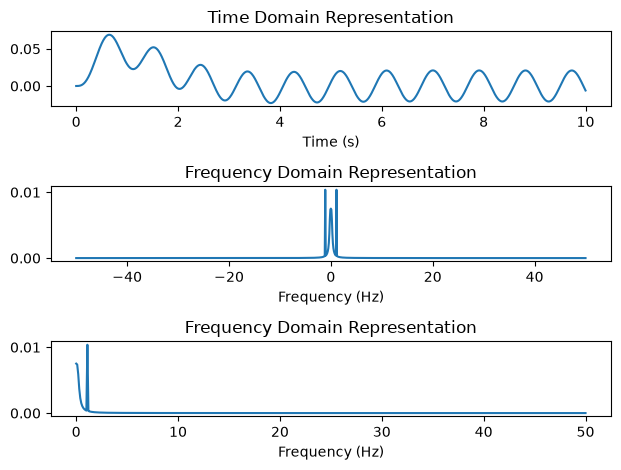

In [81]:
# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

P = ct.tf([1], [1, 2, 2])

# construct a signal that consists of a sinusoid with frequency 1.1Hz
f0 = 1.1
u = np.sin(2*np.pi*f0*t) 
t,y = ct.forced_response(P,U=u,T=t)


# Calculate the Fourier Transform using the command fft (which stands for fast Fourier Transform)
# Note that the fft command does not normalize the output, so we need to manually divide the resulting signal by N
Y = np.fft.fft(y)/N

# We need to shift the frequency axis of Sig so that 0Hz is the center frequency
Y = np.fft.fftshift(Y) 

# In this lab, we will only be interested in the magnitude of the frequency domain representation 
# (recall that typically the array Sig will be a set of complex numbers).
Y = np.abs(Y)


# Because the frequency domain is symetric about $0$Hz, we can limit the plot to positive frequencies only
Y_positive_freq = Y[500:1001]
f_positive_freq = f[500:1001]


# Plot the signal in time domain and frequency domain
fig,ax = plt.subplots(3,1)
ax[0].plot(t,y)
ax[0].set_title('Time Domain Representation')
ax[0].set_xlabel('Time (s)')
ax[1].plot(f,Y)
ax[1].set_title('Frequency Domain Representation')
ax[1].set_xlabel('Frequency (Hz)')
ax[2].plot(f_positive_freq,Y_positive_freq)
ax[2].set_title('Frequency Domain Representation')
ax[2].set_xlabel('Frequency (Hz)')
fig.tight_layout()

Estimate the magnitude of the steady state sinusoidal output. Follow these steps:
1. Truncate the output so that you remove the transient response. Call it y_trunc.
2. Trim the resulting signal so that (approximately) an integer multiple of complete sinusoids are present in the signal. Call it y_trim.
3. Calculate the Fourier Transform of that signal. Call it Y_Trim.
4. The frequency vector of y_trim can be calculated as: f_trim = np.linspace(0,100-100/N_trim,N_trim), N_trim is the length of the vector y_trim. This is the frequency vector is you do not use the fftshift command.
5. Plot y_trim
6. Plot the first N_trim/2 points of Y_Trim and f_trim. 
7. Using the code from the previous questions, calculate the magnitude of the sinusoid y_trim. 
8. Plot the time domain data and check if your estimated magnitude matches the magnitude of the time-domain signal. 

How does the frequency domain plot of Y and Y_Trim differ? Why? 

Y_Trim is much closer to a typical sinusoidal signal in the frequency domain, while Y has noise surrounding its sinusoidal components from the transient component.

Magnitude = 0.020879558193244784


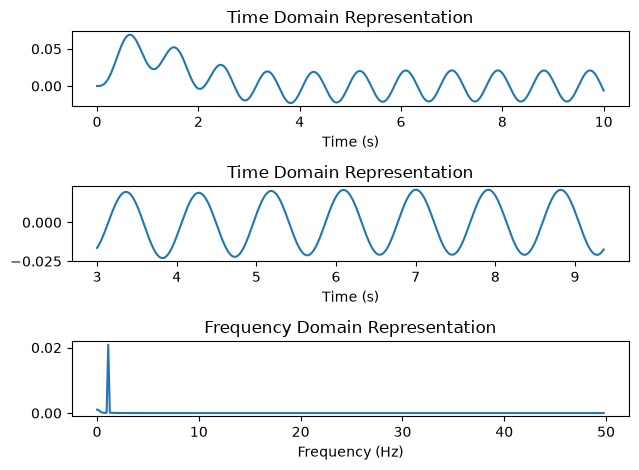

In [87]:
# Complete the following code snippet.

# setup time and frequency vectors for the plots
N = 1001
t = np.linspace(0,10,N)
f = np.linspace(-50,50,N)

P = ct.tf([1], [1, 2, 2])

# construct a signal that consists of a sinusoid with frequency 1.1Hz
f0 = 1.1
u = np.sin(2*np.pi*f0*t) 
t,y = ct.forced_response(P,U=u,T=t)

# plot output y
fig, axs = plt.subplots(3,1)
axs[0].plot(t,y)
axs[0].set_title('Time Domain Representation')
axs[0].set_xlabel('Time (s)')

y_trunc = y[300:]

y_trim = y_trunc[:7*91]
axs[1].plot(t[300:7*91+300], y_trim)
axs[1].set_title('Time Domain Representation')
axs[1].set_xlabel('Time (s)')

N_trim = len(y_trim)
Y_Trim = np.abs(np.fft.fft(y_trim) / N_trim)

N = np.shape(Y_Trim)[0]
f_trim = np.linspace(0,100-100/N,N)

hN_trim = int(N_trim / 2)

# plot Y_Trim
axs[2].plot(f_trim[:hN_trim], Y_Trim[:hN_trim] * 2)
axs[2].set_title('Frequency Domain Representation')
axs[2].set_xlabel('Frequency (Hz)')

fig.tight_layout()

print(f'Magnitude = {np.max(Y_Trim[:hN_trim] * 2)}')

# Part 3 - Setting up a Python Environment

All the labs in ENEL441 will use the following Python packages:
- numpy
- scipy
- matplotlib
- pyserial

If you do not have these packages installed, you need to install them now. I would stongly recommend setting up a virtual environment that you can use for all the ENEL441 labs. There are several ways to set up virtual environments such as using venv or conda. I prefer using miniconda, but this is a personal choice. I have written some instructions for setting up virtual environments using conda in the pdf document 'Running Jupyter Notebooks.pdf' which is on D2L in the lab folder. 

The pySerial package can be installed using the following instructions.  

## Installation:
pySerial can be installed using pip: 

>pip install pyserial

or Conda:

>conda install pyserial

Please note that you have to install pyserial, and not serial. This is a different package that confilcts with pyserial. If you have the serial package installed, you must first uninstall it, and then install pyserial. 

Run the following cell and make sure that it completes without errors. 

In [83]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import serial   # this is how you import the pyserial package! Do not install the serial package, only install the pyserial package. 
                # It is very unfortunate that you import the pyserial package with the command import serial, and that there is 
                # another package that conficts with the pyserial package named serial.  
import ENELX41_lab_util as lu  # copy the file ENELX41_lab_util.py into the same directory as this notebook, and this line should run.

### End of Pre-lab